WARP-S

In [ ]:
# download the WaRP-S segmentation dataset from Kaggle using our API token
# we only extract the Warp-S folder from the full zip to save space
import os, zipfile, shutil
import os, zipfile, shutil
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    f.write('{"username":"saivignesharra","key":"KGAT_7bd677820ee7cf31a5e7f678da2231ca"}')
os.chmod("/root/.kaggle/kaggle.json", 0o600)

!pip install kaggle -q
os.makedirs("/content/warp_s", exist_ok=True)
!kaggle datasets download parohod/warp-waste-recycling-plant-dataset \
    --path /content/warp_s

zip_path = "/content/warp_s/warp-waste-recycling-plant-dataset.zip"
with zipfile.ZipFile(zip_path) as z:
    warp_s_files = [f for f in z.namelist() if f.startswith("Warp-S/")]
    z.extractall("/content/warp_s", members=warp_s_files)
print("Extracted!")

# Save to Drive permanently
shutil.copytree("/content/warp_s/Warp-S",
                "/content/drive/MyDrive/WaRP_S",
                dirs_exist_ok=True)
print("Saved to Drive!")

Dataset URL: https://www.kaggle.com/datasets/parohod/warp-waste-recycling-plant-dataset
License(s): CC0-1.0
100% 806M/806M [00:03<00:00, 240MB/s]

Extracted!
Saved to Drive!


In [ ]:
# segmentation-models-pytorch gives us DeepLabV3+ with one line
# albumentations handles image + mask augmentation together which torchvision can't do
!pip install segmentation-models-pytorch albumentations -q
print("Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.5 MB/s eta 0:00:00
Done!


Setup, dataset, augmentations, loaders

In [ ]:
import torch, glob, numpy as np, os
import segmentation_models_pytorch as smp
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
# this forces CUDA to report errors at the exact line they happen
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

IMG_DIR   = "/content/drive/MyDrive/WaRP_S/JPEGImages"
MASK_DIR  = "/content/drive/MyDrive/WaRP_S/SegmentationObject"
N_CLASSES = 39
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device} | N_CLASSES: {N_CLASSES}")

# Clear GPU cache
if device.type == 'cuda':
    torch.cuda.empty_cache()

#  Dataset
class WaRPSegDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.images = sorted(glob.glob(f"{img_dir}/*.jpg"))
        self.masks  = sorted(glob.glob(f"{mask_dir}/*.png"))
        assert len(self.images) == len(self.masks), \
            f"Mismatch: {len(self.images)} images vs {len(self.masks)} masks"
    def __len__(self): return len(self.images)
    def get_raw(self, idx):
        image = np.array(Image.open(self.images[idx]).convert('RGB'))
        mask  = np.array(Image.open(self.masks[idx]).convert('L')).astype(np.int32)
        mask[(mask >= N_CLASSES) & (mask != 255)] = 0
        return image, mask

full_dataset = WaRPSegDataset(IMG_DIR, MASK_DIR)
print(f"Total samples: {len(full_dataset)}")

n_val   = int(0.2 * len(full_dataset))
n_train = len(full_dataset) - n_val
train_ids, val_ids = random_split(
    range(len(full_dataset)), [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)
# albumentations applies the same transform to both image and mask simultaneously
# this is important — if we flip the image we must flip the mask too
train_tf = A.Compose([
    A.Resize(height=128, width=128),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.4),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])
val_tf = A.Compose([
    A.Resize(height=128, width=128),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

# wrapper so each subset applies its own transform
class SegSubset(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset   = dataset
        self.indices   = list(indices)
        self.transform = transform
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        image, mask = self.dataset.get_raw(self.indices[idx])
        out = self.transform(image=image, mask=mask)
        return out['image'], out['mask'].long()

train_set = SegSubset(full_dataset, train_ids, train_tf)
val_set   = SegSubset(full_dataset, val_ids,   val_tf)

train_loader = DataLoader(train_set, batch_size=2, shuffle=True,
                          num_workers=2, pin_memory=False)
val_loader   = DataLoader(val_set,   batch_size=2, shuffle=False,
                          num_workers=2, pin_memory=False)

# batch size 2 - WaRP-S only has 112 images so small batches are fine
imgs, masks = next(iter(train_loader))
print(f"imgs  : {imgs.shape}")       # (2, 3, 128, 128)
print(f"masks : {masks.shape}")      # (2, 128, 128)
print(f"mask unique: {masks.unique().tolist()}")
print(f"max mask val: {masks.max().item()} — must be < {N_CLASSES}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Device: cuda | N_CLASSES: 39
Total samples: 112
imgs  : torch.Size([2, 3, 128, 128])
masks : torch.Size([2, 128, 128])
mask unique: [0, 38]
max mask val: 38 — must be < 39
Train batches: 45 | Val batches: 11


 Model, loss, optimiser

In [ ]:
# DeepLabV3+ with EfficientNet-B3 as the encoder
# we reuse the same backbone family as our classification models for consistency
# the encoder weights come from ImageNet pretraining — same approach as the classifier
seg_model = smp.DeepLabV3Plus(
    encoder_name    = 'efficientnet-b3',
    encoder_weights = 'imagenet',
    in_channels     = 3,
    classes         = N_CLASSES,
).to(device)
# ignore_index=255 tells the loss to skip boundary/unlabelled pixels
ce_loss   = torch.nn.CrossEntropyLoss(ignore_index=255)
optimizer = torch.optim.AdamW(seg_model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

print(f"Model ready — {sum(p.numel() for p in seg_model.parameters())/1e6:.1f}M params")

# quick sanity check before starting the full training run
seg_model.eval()
with torch.no_grad():
    test_imgs, test_masks = next(iter(train_loader))
    test_pred = seg_model(test_imgs.to(device))
    test_loss = ce_loss(test_pred, test_masks.to(device))
print(f"Test forward pass loss: {test_loss.item():.4f} — GPU OK!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Model ready — 11.7M params
Test forward pass loss: 3.6399 — GPU OK!


Training loop

In [ ]:
def train_epoch(model, loader, optimizer):
    model.train(); total = 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = ce_loss(model(imgs), masks)
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def val_epoch(model, loader):
    model.eval(); total = 0
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            total += ce_loss(model(imgs), masks).item()
    return total / len(loader)

def compute_miou(model, loader):
  # mIoU is the standard metric for segmentation
    # for each class we compute intersection / union and average across classes
    # pixels with value 255 are ignored in the calculation
    model.eval()
    inter = torch.zeros(N_CLASSES)
    union = torch.zeros(N_CLASSES)
    with torch.no_grad():
        for imgs, masks in loader:
            preds = model(imgs.to(device)).argmax(1).cpu()
            for c in range(N_CLASSES):
                pc     = (preds == c)
                tc     = (masks == c)
                ignore = (masks == 255)
                pc[ignore] = False
                tc[ignore] = False
                inter[c] += (pc & tc).sum().float()
                union[c] += (pc | tc).sum().float()
    iou  = inter / (union + 1e-6)
    return iou[union > 0].mean().item(), iou

EPOCHS    = 20
best_miou = 0.0
train_losses, val_losses, miou_scores = [], [], []

for epoch in range(1, EPOCHS + 1):
    t_loss  = train_epoch(seg_model, train_loader, optimizer)
    v_loss  = val_epoch(seg_model, val_loader)
    miou, _ = compute_miou(seg_model, val_loader)
    scheduler.step()

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    miou_scores.append(miou)

    if miou > best_miou:
        best_miou = miou
        torch.save(seg_model.state_dict(), 'best_seg_model.pth')
        print(f"Epoch {epoch:02d} ✓ BEST | train={t_loss:.4f} val={v_loss:.4f} mIoU={miou:.4f}")
    else:
        print(f"Epoch {epoch:02d}       | train={t_loss:.4f} val={v_loss:.4f} mIoU={miou:.4f}")

print(f"\nBest mIoU: {best_miou:.4f}")

Epoch 01 ✓ BEST | train=3.1483 val=3.0413 mIoU=0.0314
Epoch 02 ✓ BEST | train=2.0010 val=2.1126 mIoU=0.1549
Epoch 03 ✓ BEST | train=1.3557 val=1.5703 mIoU=0.5505
Epoch 04 ✓ BEST | train=1.0261 val=1.1815 mIoU=0.5842
Epoch 05 ✓ BEST | train=0.8009 val=0.9511 mIoU=0.6259
Epoch 06 ✓ BEST | train=0.6720 val=0.8310 mIoU=0.6265
Epoch 07 ✓ BEST | train=0.5842 val=0.7452 mIoU=0.6433
Epoch 08 ✓ BEST | train=0.5074 val=0.6760 mIoU=0.6497
Epoch 09 ✓ BEST | train=0.4767 val=0.6362 mIoU=0.6646
Epoch 10 ✓ BEST | train=0.4190 val=0.5920 mIoU=0.6705
Epoch 11       | train=0.3901 val=0.5830 mIoU=0.6691
Epoch 12 ✓ BEST | train=0.3852 val=0.5638 mIoU=0.6755
Epoch 13 ✓ BEST | train=0.3663 val=0.5331 mIoU=0.6849
Epoch 14       | train=0.3579 val=0.5254 mIoU=0.6847
Epoch 15 ✓ BEST | train=0.3503 val=0.5311 mIoU=0.6858
Epoch 16       | train=0.3230 val=0.5394 mIoU=0.6827
Epoch 17 ✓ BEST | train=0.3100 val=0.5300 mIoU=0.6865
Epoch 18       | train=0.3135 val=0.5239 mIoU=0.6865
Epoch 19 ✓ BEST | train=0.3088 v

Plots and visualisation

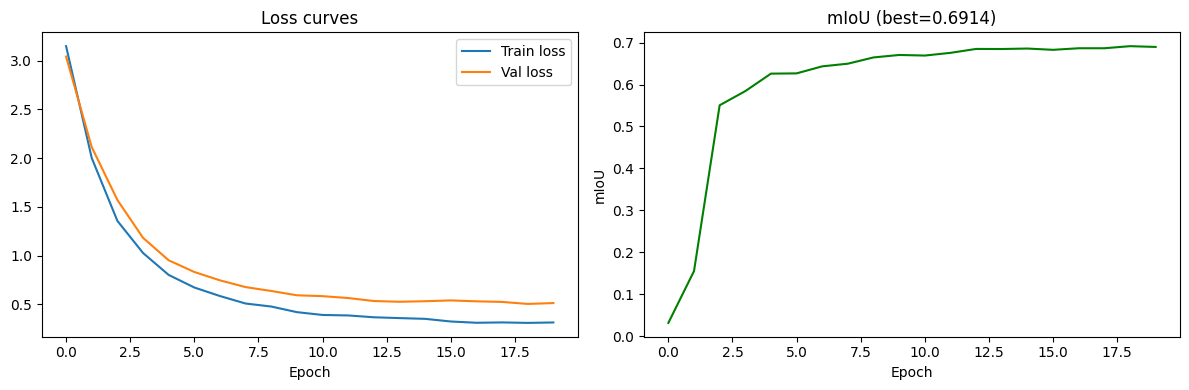

/tmp/ipykernel_5763/3953372438.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', N_CLASSES)


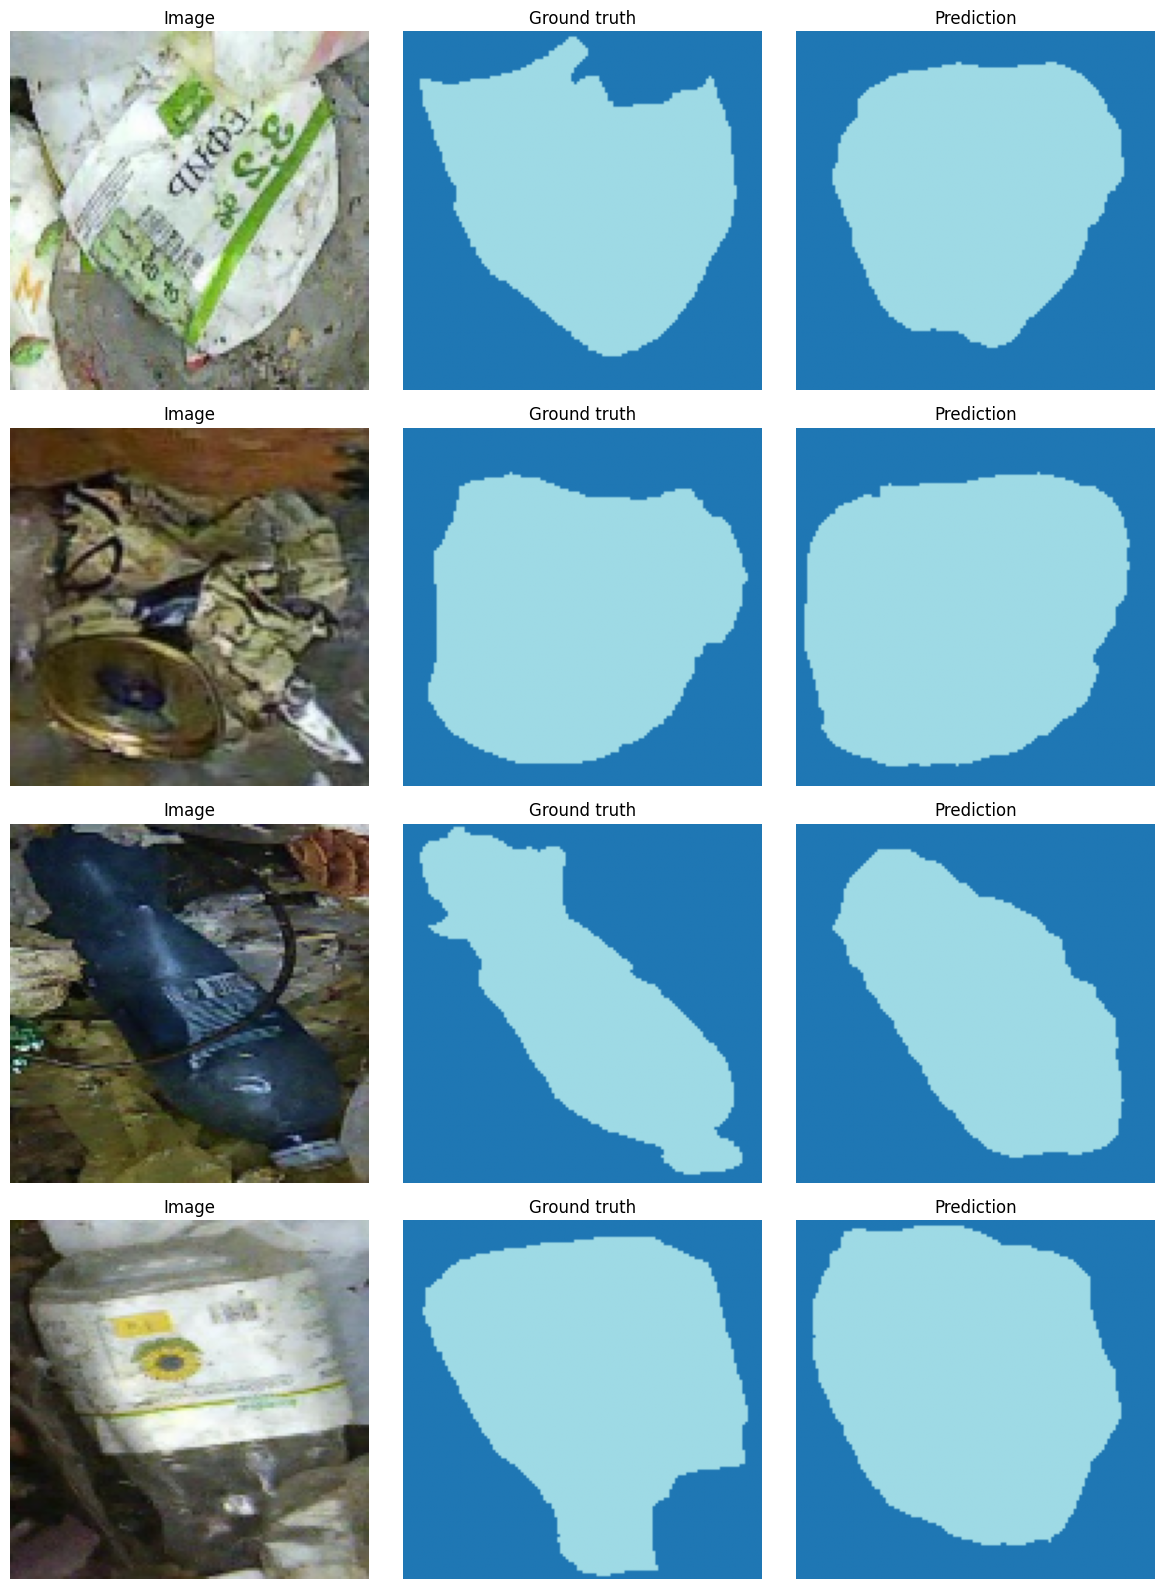

All figures saved!


In [ ]:
# loss and mIoU curves side by side for the report
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train loss')
ax1.plot(val_losses,   label='Val loss')
ax1.set_title('Loss curves'); ax1.legend(); ax1.set_xlabel('Epoch')
ax2.plot(miou_scores, color='green')
ax2.set_title(f'mIoU (best={best_miou:.4f})')
ax2.set_ylabel('mIoU'); ax2.set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('seg_loss_curves.png', dpi=150); plt.show()
# load best model and show 4 predictions vs ground truth
seg_model.load_state_dict(torch.load('best_seg_model.pth'))
seg_model.eval()
cmap = plt.cm.get_cmap('tab20', N_CLASSES)

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
for i in range(4):
    img_t, mask_t = val_set[i]
    with torch.no_grad():
        pred = seg_model(img_t.unsqueeze(0).to(device)).argmax(1).squeeze().cpu()
    img_np = img_t.permute(1,2,0).numpy()
    img_np = img_np * [0.229,0.224,0.225] + [0.485,0.456,0.406]
    img_np = np.clip(img_np, 0, 1)
    axes[i,0].imshow(img_np);                                    axes[i,0].set_title('Image')
    axes[i,1].imshow(mask_t, cmap=cmap, vmin=0, vmax=N_CLASSES); axes[i,1].set_title('Ground truth')
    axes[i,2].imshow(pred,   cmap=cmap, vmin=0, vmax=N_CLASSES); axes[i,2].set_title('Prediction')
    for ax in axes[i]: ax.axis('off')
plt.tight_layout()
plt.savefig('seg_predictions.png', dpi=150); plt.show()
print("All figures saved!")